In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
#QUESTION 2: Load Dataset
df = pd.read_csv("Student Awareness Survey (Responses) - Form Responses 1.csv")

print(df.head())

           Timestamp  Registration Number  \
0  6/15/2026 9:25:39              2547231   
1  6/15/2026 9:53:54              2547237   
2  6/15/2026 9:54:56              2547203   
3  6/15/2026 9:55:17              2547228   
4  6/15/2026 9:55:42              2547241   

                                        Email  \
0       kunnal.kunnal@mca.christuniversity.in   
1  omkaar.chakraborty@mca.christuniversity.in   
2        abhinav.jain@mca.christuniversity.in   
3          jai.pareek@mca.christuniversity.in   
4             r.karan@mca.christuniversity.in   

   Job role that you are interested in  \
0  Software Development Engineer (SDE)   
1  Software Development Engineer (SDE)   
2                 Full Stack Developer   
3                 Full Stack Developer   
4  Software Development Engineer (SDE)   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                                                3.5                                 

In [7]:
#Question 3: Display Dataset Information
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(50, 15)

Columns:
Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company that recruits from campus?',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'Your CIA % of last semester', 'Your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                             

In [9]:
#Question 4: Check Missing Values
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package ex

In [11]:
#Question 5: Select Required Columns
df = df[[
    'Your GPA of last semester',
    'What are your package expectations (LPA)'
]]

print(df.head())

   Your GPA of last semester What are your package expectations (LPA)
0                       3.40                                        8
1                       3.69                                       12
2                       3.41                                       12
3                       3.60                                  1200000
4                       3.54                                       12


In [13]:
#Question 6: Convert Package Column to Numeric
df['What are your package expectations (LPA)'] = pd.to_numeric(
    df['What are your package expectations (LPA)'],
    errors='coerce'
)

print(df.dtypes)

Your GPA of last semester                   float64
What are your package expectations (LPA)    float64
dtype: object


In [15]:
#Question 7: Handle Missing Values



print("Before Cleaning")

print(df.isnull().sum())

df = df.dropna()

print("\nAfter Cleaning")

print(df.isnull().sum())

Before Cleaning
Your GPA of last semester                   0
What are your package expectations (LPA)    0
dtype: int64

After Cleaning
Your GPA of last semester                   0
What are your package expectations (LPA)    0
dtype: int64


Rows Before: 36
Rows After: 36


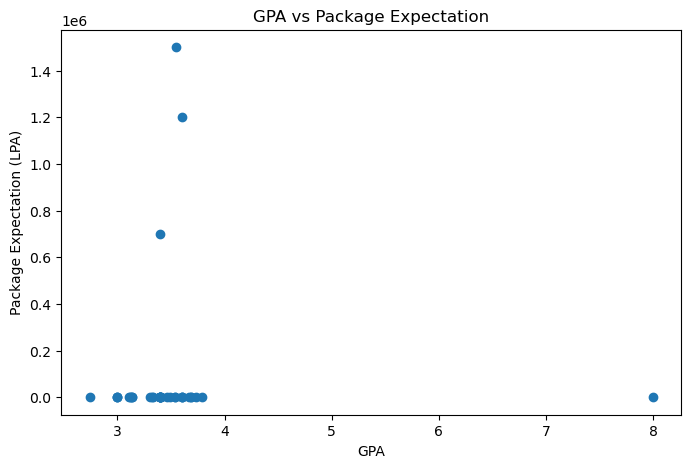

In [17]:
#Question 8–10: Remove Duplicates + Visualization + Define X and Y
# Remove Duplicates
print("Rows Before:", len(df))
df = df.drop_duplicates()
print("Rows After:", len(df))

# Visualization
plt.figure(figsize=(8,5))
plt.scatter(
    df['Your GPA of last semester'],
    df['What are your package expectations (LPA)']
)

plt.xlabel("GPA")
plt.ylabel("Package Expectation (LPA)")
plt.title("GPA vs Package Expectation")
plt.show()

# Define X and Y
X = df[['Your GPA of last semester']]
y = df['What are your package expectations (LPA)']

In [19]:
#Question 11–13: Split Data + Train Model + Regression Equation
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Regression Equation
slope = model.coef_[0]
intercept = model.intercept_

print("Slope =", slope)
print("Intercept =", intercept)

print(f"\nRegression Equation:")
print(f"Package = {slope:.4f} × GPA + {intercept:.4f}")

Slope = 248985.276740919
Intercept = -726710.1676981734

Regression Equation:
Package = 248985.2767 × GPA + -726710.1677


R² Score = -5409413486.093728


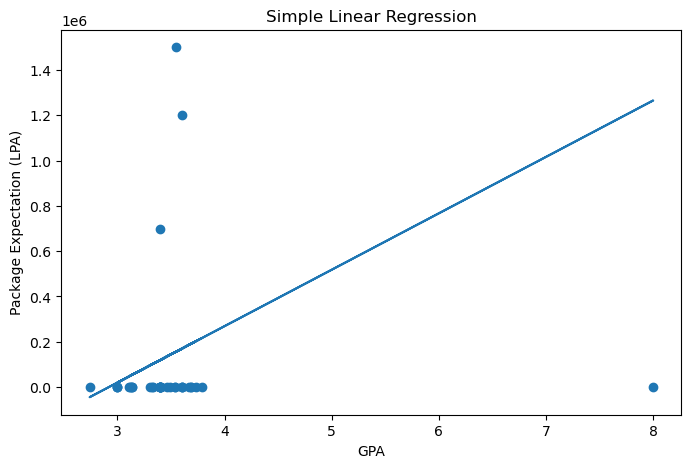

In [21]:
#Question 14–16: Predictions + Regression Line + R² Score
# Predictions
y_pred = model.predict(X_test)

# R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score =", r2)

# Regression Line
plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X)
)

plt.xlabel("GPA")
plt.ylabel("Package Expectation (LPA)")
plt.title("Simple Linear Regression")

plt.show()

In [22]:
#Question 17–18: Manual OLS + Comparison
# Manual OLS

x = df['Your GPA of last semester']
y_actual = df['What are your package expectations (LPA)']

n = len(df)

m = (
    n*np.sum(x*y_actual)
    - np.sum(x)*np.sum(y_actual)
) / (
    n*np.sum(x*x)
    - (np.sum(x))**2
)

c = np.mean(y_actual) - m*np.mean(x)

print("Manual Slope =", m)
print("Manual Intercept =", c)

# Comparison Table

comparison = pd.DataFrame({
    'Method':['Scikit-Learn','Manual OLS'],
    'Slope':[slope,m],
    'Intercept':[intercept,c]
})

print("\nComparison")
print(comparison)

Manual Slope = 3460.2473419023067
Manual Intercept = 82297.31427007716

Comparison
         Method          Slope      Intercept
0  Scikit-Learn  248985.276741 -726710.167698
1    Manual OLS    3460.247342   82297.314270
